In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display all columns
pd.set_option("display.max_columns", None)

# Better formatting for floats
pd.options.display.float_format = "{:,.2f}".format

Matplotlib is building the font cache; this may take a moment.


In [16]:
pip install xlrd

Note: you may need to restart the kernel to use updated packages.


In [17]:
file_path = "../data/raw/Global_Superstore.xls"
#data/raw/Global_Superstore.xls
excel_file = pd.ExcelFile(file_path)

print(excel_file.sheet_names)

['Orders', 'People', 'Returns']


In [18]:
orders = pd.read_excel(file_path, sheet_name="Orders")
returns = pd.read_excel(file_path, sheet_name="Returns")
people = pd.read_excel(file_path, sheet_name="People")

In [19]:
print("Orders")
display(orders.head())

print("Returns")
display(returns.head())

print("People")
display(people.head())

Orders


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,State/Province,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2020-103800,2020-01-03,2020-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,Texas,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.45,2,0.20,5.55
1,2,US-2020-112326,2020-01-04,2020-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.54,2,0.80,-5.49
2,3,US-2020-112326,2020-01-04,2020-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.78,3,0.20,4.27
3,4,US-2020-112326,2020-01-04,2020-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.74,3,0.20,-64.77
4,5,US-2020-141817,2020-01-05,2020-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,Pennsylvania,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.54,3,0.20,4.88


Returns


,Returned,Order ID
0,Yes,US-2020-100762
1,Yes,US-2020-100762
2,Yes,US-2020-100762
3,Yes,US-2020-100762
4,Yes,US-2020-100867


People


,Regional Manager,Region
0,Sadie Pawthorne,West
1,Chuck Magee,East
2,Roxanne Rodriguez,Central
3,Fred Suzuki,South


In [20]:
print("Orders Shape:", orders.shape)
print("Returns Shape:", returns.shape)
print("People Shape:", people.shape)

Orders Shape: (10194, 21)
Returns Shape: (800, 2)
People Shape: (4, 2)


In [21]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          10194 non-null  int64         
 1   Order ID        10194 non-null  str           
 2   Order Date      10194 non-null  datetime64[us]
 3   Ship Date       10194 non-null  datetime64[us]
 4   Ship Mode       10194 non-null  str           
 5   Customer ID     10194 non-null  str           
 6   Customer Name   10194 non-null  str           
 7   Segment         10194 non-null  str           
 8   Country/Region  10194 non-null  str           
 9   City            10194 non-null  str           
 10  State/Province  10194 non-null  str           
 11  Postal Code     10194 non-null  str           
 12  Region          10194 non-null  str           
 13  Product ID      10194 non-null  str           
 14  Category        10194 non-null  str           
 15  Sub-Category 

In [23]:
orders.describe()

,Row ID,Order Date,Ship Date,Sales,Quantity,Discount,Profit
count,"10,194.00",10194,10194,"10,194.00","10,194.00","10,194.00","10,194.00"
mean,"5,097.50",2022-04-29 16:37:51.453796,2022-05-03 15:41:38.175397,228.23,3.79,0.16,28.67
min,1.00,2020-01-03 00:00:00,2020-01-07 00:00:00,0.44,1.00,0.00,"-6,599.98"
25%,"2,549.25",2021-05-14 00:00:00,2021-05-19 00:00:00,17.22,2.00,0.00,1.76
50%,"5,097.50",2022-06-25 00:00:00,2022-06-28 00:00:00,53.91,3.00,0.20,8.69
75%,"7,645.75",2023-05-14 00:00:00,2023-05-18 00:00:00,209.50,5.00,0.20,29.30
max,"10,194.00",2023-12-30 00:00:00,2024-01-05 00:00:00,"22,638.48",14.00,0.80,"8,399.98"
std,"2,942.90",NaN,NaN,619.91,2.23,0.21,232.47


In [22]:
orders.describe(include="object")

C:\Users\agraw\AppData\Local\Temp\ipykernel_43752\3661551341.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  orders.describe(include="object")


,Order ID,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,State/Province,Postal Code,Region,Product ID,Category,Sub-Category,Product Name
count,10194,10194,10194,10194,10194,10194,10194,10194,10194,10194,10194,10194,10194,10194
unique,5111,4,804,800,3,2,542,59,654,4,1862,3,17,1849
top,US-2023-100111,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,10035,West,FUR-FU-10004270,Office Supplies,Binders,Staples
freq,14,6120,41,41,5281,9994,915,2001,263,3253,20,6128,1548,50


In [24]:
missing = orders.isnull().sum()

missing = missing[missing > 0]

missing.sort_values(ascending=False)

Series([], dtype: int64)

In [25]:
duplicates = orders.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


In [26]:
orders["Customer ID"].nunique()

804

In [27]:
orders["Product ID"].nunique()

1862

In [28]:
orders["Category"].unique()

<StringArray>
['Office Supplies', 'Furniture', 'Technology']
Length: 3, dtype: str

In [29]:
orders["Region"].unique()

<StringArray>
['Central', 'East', 'South', 'West']
Length: 4, dtype: str

In [31]:
orders["Country/Region"].unique()

<StringArray>
['United States', 'Canada']
Length: 2, dtype: str

In [32]:
orders["Order Date"] = pd.to_datetime(orders["Order Date"])

print("First Order:", orders["Order Date"].min())
print("Last Order :", orders["Order Date"].max())

First Order: 2020-01-03 00:00:00
Last Order : 2023-12-30 00:00:00


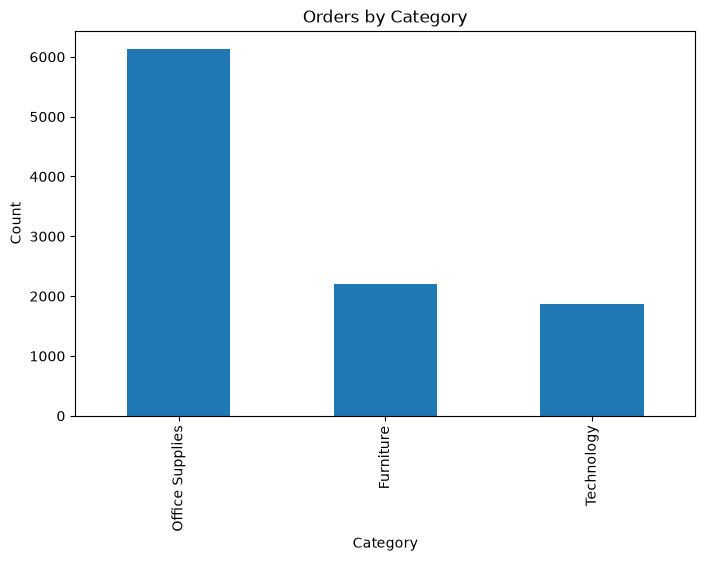

In [34]:
orders["Category"].value_counts().plot(
    kind="bar",
    figsize=(8,5),
    title="Orders by Category"
)

plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

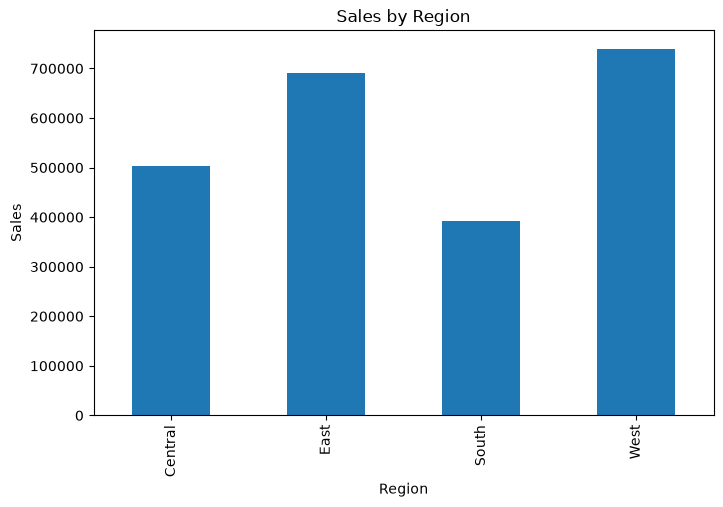

In [35]:
region_sales = orders.groupby("Region")["Sales"].sum()

region_sales.plot(
    kind="bar",
    figsize=(8,5),
    title="Sales by Region"
)

plt.ylabel("Sales")
plt.show()